# 01. Database and Dataset Construction

This notebook reconstructs the dataset used in the project from the Prado database. The goal is to understand coverage across the available tables, identify which artworks contain the necessary visual and textual information, and progressively build the final datasets used for analysis and modeling.

## 1. Database coverage overview

As a first step, I checked how many artworks are available in the main database and how many of them are linked to the tables needed for this project, such as images, textual descriptors, SADCAT scores, figure annotations, and generated captions. This helps clarify the effective size of the usable dataset before any filtering is applied.

In [6]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
db_path = "/home/agrupa-lab/agrupa/agrupa.sqlite"
conn = sqlite3.connect(db_path)

# Coverage queries
queries = {
    "total_artworks": "SELECT COUNT(*) AS n FROM artwork",
    "with_image": "SELECT COUNT(DISTINCT cat_no) AS n FROM artwork_image",
    "with_sadcat": "SELECT COUNT(DISTINCT cat_no) AS n FROM artwork_sadcat",
    "with_descriptors": "SELECT COUNT(DISTINCT cat_no) AS n FROM artwork_descriptor",
    "with_figures": "SELECT COUNT(DISTINCT cat_no) AS n FROM figures_m",
    "with_captions": "SELECT COUNT(DISTINCT cat_no) AS n FROM qwen_captions_m"
}

# Run queries and collect results
rows = []
for metric, query in queries.items():
    n = pd.read_sql_query(query, conn).iloc[0, 0]
    rows.append({"metric": metric, "n": n})

coverage_df = pd.DataFrame(rows)
coverage_df

,metric,n
0,total_artworks,15455
1,with_image,7429
2,with_sadcat,6888
3,with_descriptors,6888
4,with_figures,6093
5,with_captions,6266


The coverage overview shows that the full Prado database contains 15,455 artworks, but only a subset includes the information needed for this project. In particular, 7,429 artworks are linked to local images, while 6,888 contain descriptor and SADCAT information. This already suggests that the final usable dataset will be limited by the overlap between the visual and textual branches of the analysis.

In [7]:
# Add percentage coverage relative to the full artwork table
total_artworks = coverage_df.loc[coverage_df["metric"] == "total_artworks", "n"].iloc[0]

coverage_df["pct_of_total"] = (coverage_df["n"] / total_artworks * 100).round(2)
coverage_df

,metric,n,pct_of_total
0,total_artworks,15455,100.00
1,with_image,7429,48.07
2,with_sadcat,6888,44.57
3,with_descriptors,6888,44.57
4,with_figures,6093,39.42
5,with_captions,6266,40.54


## 2. Inspecting database structure and key variables

Before constructing the final dataset, it is important to understand the structure of the different tables and how they can be joined together. In particular, we examine the main columns available for artworks, descriptors, SADCAT scores, and image references.

This step helps define how the final dataset will be built and ensures that all required variables are correctly aligned across tables.

In [8]:
import sqlite3
import pandas as pd

# Connect to the database
db_path = "/home/agrupa-lab/agrupa/agrupa.sqlite"
conn = sqlite3.connect(db_path)

# Inspect the structure of the main tables used in the project
tables_to_check = [
    "artwork",
    "artwork_image",
    "artwork_descriptor",
    "artwork_sadcat"
]

for table in tables_to_check:
    sample_df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3", conn)
    print(f"\n{'='*60}")
    print(f"Table: {table}")
    print(f"{'='*60}")
    print("\nColumns:")
    print(list(sample_df.columns))
    print("\nSample rows:")
    display(sample_df)

conn.close()


Table: artwork

Columns:
['cat_no', 'titulo', 'autor', 'escuela_obra', 'ubicacion', 'medidas', 'tecnicas', 'soporte', 'materia', 'otros_no_inv', 'fecha_ingreso', 'forma_ingreso', 'procedencia', 'tipo_objeto', 'datacion', 'tema', 'pais_ubicacion', 'comunidad_ubicacion', 'provincia_ubicacion', 'localidad_ubicacion', 'area_departamento', 'marco_obra_actual', 'is_religious', 'is_fauna', 'century', 'image_path', 'descripcion', 'animal_cluster']

Sample rows:


,cat_no,titulo,autor,escuela_obra,ubicacion,medidas,tecnicas,soporte,materia,otros_no_inv,...,provincia_ubicacion,localidad_ubicacion,area_departamento,marco_obra_actual,is_religious,is_fauna,century,image_path,descripcion,animal_cluster
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,"Sala 6 (Planta 1, Sector Norte) - Edificio Vil...",Alto: 113 cm; Ancho: 171 cm; Alto del marco: 1...,Óleo,Lienzo,None,"Catálogo Museo del Prado, 1872-1907 - 2; Inv. ...",...,"Madrid, Provincia de",Madrid,Pintura italiana del Barroco,M000231,0,1,17th c.,obras/P000002.jpg,"La obra de Francesco Albani, uno de los discíp...",purity
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,(Almacén),Alto: 263 cm; Ancho: 201 cm; Alto del marco: 2...,Óleo,Lienzo,None,"Catálogo Museo de la Trinidad, 1865 - 121; Inv...",...,"Madrid, Provincia de",Madrid,Pintura italiana del Renacimiento,M007774,1,1,16th c.,obras/P000006.jpg,"San José, la Virgen con el Niño en brazos y Sa...",other
2,P000013,Rendición de Sevilla al rey san Fernando,"Flipart, Charles-Joseph",Francesa,(Almacén),"Alto: 72 cm; Ancho: 56 cm; Alto del marco: 84,...",Óleo,Lienzo,None,"Inv. Real Museo, 1857 - 1107; Catálogo Museo d...",...,"Madrid, Provincia de",Madrid,Pintura del siglo XVIII y Goya,M007022,0,1,18th c.,obras/P000013.jpg,"Fernando III, con la espada y el globo del mun...",power



Table: artwork_image

Columns:
['cat_no', 'file_name', 'file_path', 'extension', 'file_size_kb']

Sample rows:


,cat_no,file_name,file_path,extension,file_size_kb
0,G005081,G005081.jpg,/home/agrupa-lab/agrupa/data_raw/obras/G005081...,.jpg,224.85
1,G005082,G005082.jpg,/home/agrupa-lab/agrupa/data_raw/obras/G005082...,.jpg,158.11
2,G005084,G005084.jpg,/home/agrupa-lab/agrupa/data_raw/obras/G005084...,.jpg,163.83



Table: artwork_descriptor

Columns:
['cat_no', 'descriptor']

Sample rows:


,cat_no,descriptor
0,P000002,obra
1,P000002,francesco
2,P000002,albani



Table: artwork_sadcat

Columns:
['cat_no', 'n_descriptores_fila', 'n_en_diccionario_fila', 'cov_pct_global', 'cov_Sociability_dict_pct', 'cov_Morality_dict_pct', 'cov_Ability_dict_pct', 'cov_Agency_dict_pct', 'cov_health_dict_pct', 'cov_Status_dict_pct', 'cov_work_dict_pct', 'cov_Politics_dict_pct', 'cov_Religion_dict_pct', 'cov_beliefsother_dict_pct', 'cov_inhabitant_dict_pct', 'cov_country_dict_pct', 'cov_feeling_dict_pct', 'cov_relative_dict_pct', 'cov_clothing_dict_pct', 'cov_ordinariness_dict_pct', 'cov_bodpart_dict_pct', 'cov_bodprop_dict_pct', 'cov_skin_dict_pct', 'cov_bodcov_dict_pct', 'cov_beauty_dict_pct', 'cov_insults_dict_pct', 'cov_stem_dict_pct', 'cov_humanities_dict_pct', 'cov_art_dict_pct', 'cov_socialgroups_dict_pct', 'cov_Lacksknowledge_dict_pct', 'cov_fortune_dict_pct', 'cov_Sociability_dict_hi_pct', 'cov_Sociability_dict_lo_pct', 'cov_Morality_dict_hi_pct', 'cov_Morality_dict_lo_pct', 'cov_Ability_dict_hi_pct', 'cov_Ability_dict_lo_pct', 'cov_Agency_dict_hi_pct', '

,cat_no,n_descriptores_fila,n_en_diccionario_fila,cov_pct_global,cov_Sociability_dict_pct,cov_Morality_dict_pct,cov_Ability_dict_pct,cov_Agency_dict_pct,cov_health_dict_pct,cov_Status_dict_pct,...,dirmean_beauty,n_dirmean_beauty,dirmean_Warmth,n_dirmean_Warmth,dirmean_Competence,n_dirmean_Competence,dirmean_Beliefs,n_dirmean_Beliefs,dirmean_Beliefs_ABC,n_dirmean_Beliefs_ABC
0,P000002,890.0,62.0,6.966292,0.449438,0.561798,0.449438,0.674157,0.449438,0.449438,...,1.0,4,0.333333,9,0.7,10,0.583333,12,0.583333,12
1,P000006,148.0,17.0,11.486486,0.675676,2.702703,1.351351,0.675676,2.027027,0.000000,...,NaN,0,0.937500,4,0.5,2,0.714286,7,0.714286,7
2,P000013,183.0,17.0,9.289617,0.000000,0.546448,0.546448,0.000000,0.000000,0.000000,...,NaN,0,1.000000,1,1.0,1,0.750000,4,0.750000,4


Although the database contains many variables, only a subset is needed for this project. The most important fields are the catalogue identifier (`cat_no`), the textual description, the image path, selected metadata for later subgroup analysis, and the SADCAT-derived warmth and competence scores together with their descriptor counts.

In [9]:
# Select the key columns that will be used later in the analysis

artwork_cols = [
    "cat_no", "titulo", "autor", "escuela_obra", "tipo_objeto",
    "datacion", "tema", "is_religious", "is_fauna", "century",
    "image_path", "descripcion", "animal_cluster"
]

sadcat_cols = [
    "cat_no",
    "n_descriptores_fila",
    "n_en_diccionario_fila",
    "dirmean_Warmth", "n_dirmean_Warmth",
    "dirmean_Competence", "n_dirmean_Competence"
]

print("Key columns from artwork:")
print(artwork_cols)

print("\nKey columns from artwork_sadcat:")
print(sadcat_cols)

Key columns from artwork:
['cat_no', 'titulo', 'autor', 'escuela_obra', 'tipo_objeto', 'datacion', 'tema', 'is_religious', 'is_fauna', 'century', 'image_path', 'descripcion', 'animal_cluster']

Key columns from artwork_sadcat:
['cat_no', 'n_descriptores_fila', 'n_en_diccionario_fila', 'dirmean_Warmth', 'n_dirmean_Warmth', 'dirmean_Competence', 'n_dirmean_Competence']


In [10]:
# Load only the key columns for a cleaner preview

conn = sqlite3.connect(db_path)

artwork_key = pd.read_sql_query(
    f"SELECT {', '.join(artwork_cols)} FROM artwork LIMIT 5", conn
)

sadcat_key = pd.read_sql_query(
    f"SELECT {', '.join(sadcat_cols)} FROM artwork_sadcat LIMIT 5", conn
)

conn.close()

display(artwork_key)
display(sadcat_key)

,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,image_path,descripcion,animal_cluster
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,None,0,1,17th c.,obras/P000002.jpg,"La obra de Francesco Albani, uno de los discíp...",purity
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,None,1,1,16th c.,obras/P000006.jpg,"San José, la Virgen con el Niño en brazos y Sa...",other
2,P000013,Rendición de Sevilla al rey san Fernando,"Flipart, Charles-Joseph",Francesa,Cuadro Boceto,Segunda mitad del siglo XVIII,None,0,1,18th c.,obras/P000013.jpg,"Fernando III, con la espada y el globo del mun...",power
3,P000014,"María Isabel de Borbón y Sajonia, infanta de N...","Ruta, Clemente",Italiana,Pintura,Hacia 1746,None,0,1,18th c.,obras/P000014.jpg,"Algo más de medio cuerpo, con un perrillo bajo...",other
4,P000015,La Anunciación,"Angelico, Fra",Toscana,Pintura,1425 - 1426,None,1,1,15th c.,obras/P000015.jpg,"La escena principal muestra la Anunciación y, ...",other


,cat_no,n_descriptores_fila,n_en_diccionario_fila,dirmean_Warmth,n_dirmean_Warmth,dirmean_Competence,n_dirmean_Competence
0,P000002,890.0,62.0,0.333333,9,0.7,10
1,P000006,148.0,17.0,0.937500,4,0.5,2
2,P000013,183.0,17.0,1.000000,1,1.0,1
3,P000014,251.0,14.0,-1.000000,2,1.0,1
4,P000015,432.0,26.0,1.000000,4,1.0,1


## 3. Constructing the master dataset

After identifying the relevant variables, the next step is to construct a unified dataset that combines visual metadata from the artwork table with stereotype-related scores from the SADCAT table.

The merge is performed using the catalogue identifier (`cat_no`), which acts as the common key across all tables. This step produces the base dataset used in all subsequent analysis and modeling.

In [11]:
# Reconnect to database
conn = sqlite3.connect(db_path)

# Load selected columns
artwork_df = pd.read_sql_query(
    f"SELECT {', '.join(artwork_cols)} FROM artwork", conn
)

sadcat_df = pd.read_sql_query(
    f"SELECT {', '.join(sadcat_cols)} FROM artwork_sadcat", conn
)

conn.close()

# Merge datasets on cat_no
master_df = artwork_df.merge(sadcat_df, on="cat_no", how="inner")

print("Master dataset shape:", master_df.shape)
master_df.head()

Master dataset shape: (6888, 19)


,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,image_path,descripcion,animal_cluster,n_descriptores_fila,n_en_diccionario_fila,dirmean_Warmth,n_dirmean_Warmth,dirmean_Competence,n_dirmean_Competence
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,None,0,1,17th c.,obras/P000002.jpg,"La obra de Francesco Albani, uno de los discíp...",purity,890.0,62.0,0.333333,9,0.7,10
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,None,1,1,16th c.,obras/P000006.jpg,"San José, la Virgen con el Niño en brazos y Sa...",other,148.0,17.0,0.937500,4,0.5,2
2,P000013,Rendición de Sevilla al rey san Fernando,"Flipart, Charles-Joseph",Francesa,Cuadro Boceto,Segunda mitad del siglo XVIII,None,0,1,18th c.,obras/P000013.jpg,"Fernando III, con la espada y el globo del mun...",power,183.0,17.0,1.000000,1,1.0,1
3,P000014,"María Isabel de Borbón y Sajonia, infanta de N...","Ruta, Clemente",Italiana,Pintura,Hacia 1746,None,0,1,18th c.,obras/P000014.jpg,"Algo más de medio cuerpo, con un perrillo bajo...",other,251.0,14.0,-1.000000,2,1.0,1
4,P000015,La Anunciación,"Angelico, Fra",Toscana,Pintura,1425 - 1426,None,1,1,15th c.,obras/P000015.jpg,"La escena principal muestra la Anunciación y, ...",other,432.0,26.0,1.000000,4,1.0,1


In [12]:
# Check missing values in key variables
master_df[[
    "dirmean_Warmth",
    "dirmean_Competence",
    "image_path"
]].isna().sum()

dirmean_Warmth        1574
dirmean_Competence    2148
image_path               0
dtype: int64

## 4. Filtering the dataset and defining analysis subsets

The merged dataset still includes artworks with uneven levels of textual coverage. Since the SADCAT-derived warmth and competence scores depend on the presence of enough matched descriptors, additional filtering is needed before modeling.

To address this, I define different dataset versions. First, I keep only artworks with an associated image, since visual analysis is not possible otherwise. Then, I construct a stricter subset requiring stronger textual evidence for warmth and competence. In parallel, I also retain a more inclusive version in which missing stereotype scores can later be interpreted as absence of signal rather than complete data loss.

In [13]:
# Build a cleaner base dataset using the variables needed for analysis

base_df = master_df.copy()

# Keep only artworks with an image
base_df = base_df[base_df["image_path"].notna()].copy()

print("Base dataset shape (artworks with image):", base_df.shape)
base_df.head()

Base dataset shape (artworks with image): (6888, 19)


,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,image_path,descripcion,animal_cluster,n_descriptores_fila,n_en_diccionario_fila,dirmean_Warmth,n_dirmean_Warmth,dirmean_Competence,n_dirmean_Competence
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,None,0,1,17th c.,obras/P000002.jpg,"La obra de Francesco Albani, uno de los discíp...",purity,890.0,62.0,0.333333,9,0.7,10
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,None,1,1,16th c.,obras/P000006.jpg,"San José, la Virgen con el Niño en brazos y Sa...",other,148.0,17.0,0.937500,4,0.5,2
2,P000013,Rendición de Sevilla al rey san Fernando,"Flipart, Charles-Joseph",Francesa,Cuadro Boceto,Segunda mitad del siglo XVIII,None,0,1,18th c.,obras/P000013.jpg,"Fernando III, con la espada y el globo del mun...",power,183.0,17.0,1.000000,1,1.0,1
3,P000014,"María Isabel de Borbón y Sajonia, infanta de N...","Ruta, Clemente",Italiana,Pintura,Hacia 1746,None,0,1,18th c.,obras/P000014.jpg,"Algo más de medio cuerpo, con un perrillo bajo...",other,251.0,14.0,-1.000000,2,1.0,1
4,P000015,La Anunciación,"Angelico, Fra",Toscana,Pintura,1425 - 1426,None,1,1,15th c.,obras/P000015.jpg,"La escena principal muestra la Anunciación y, ...",other,432.0,26.0,1.000000,4,1.0,1


In [14]:
# Check missing target values before defining subsets

missing_summary = base_df[[
    "dirmean_Warmth",
    "dirmean_Competence",
    "n_dirmean_Warmth",
    "n_dirmean_Competence"
]].isna().sum().to_frame(name="missing_count")

missing_summary

,missing_count
dirmean_Warmth,1574
dirmean_Competence,2148
n_dirmean_Warmth,0
n_dirmean_Competence,0


In [42]:
# Strict dataset (main dataset for modeling)
# - image exists (already ensured)
# - at least 10 descriptors
# - valid warmth & competence
# - at least 2 matched words per dimension

strict_df = base_df[
    (base_df["n_descriptores_fila"] >= 10) &
    base_df["dirmean_Warmth"].notna() &
    base_df["dirmean_Competence"].notna() &
    (base_df["n_dirmean_Warmth"] >= 2) &
    (base_df["n_dirmean_Competence"] >= 2)
].copy()

print("Strict dataset shape:", strict_df.shape)

Strict dataset shape: (3198, 19)


In [43]:
# Neutral-imputed dataset (robustness dataset)
# - at least 10 descriptors
# - missing warmth/competence replaced with 0.5

neutral_df = base_df[
    base_df["n_descriptores_fila"] >= 10
].copy()

neutral_df["warmth_was_missing"] = neutral_df["dirmean_Warmth"].isna().astype(int)
neutral_df["competence_was_missing"] = neutral_df["dirmean_Competence"].isna().astype(int)

neutral_df["dirmean_Warmth"] = neutral_df["dirmean_Warmth"].fillna(0.5)
neutral_df["dirmean_Competence"] = neutral_df["dirmean_Competence"].fillna(0.5)

print("Neutral-imputed dataset shape:", neutral_df.shape)

Neutral-imputed dataset shape: (6856, 21)


In [46]:
final_dataset_summary = pd.DataFrame({
    "dataset_version": ["strict", "neutral_imputed"],
    "n_artworks": [len(strict_df), len(neutral_df)],
    "n_columns": [strict_df.shape[1], neutral_df.shape[1]]
})

final_dataset_summary

,dataset_version,n_artworks,n_columns
0,strict,3198,19
1,neutral_imputed,6856,21


In [47]:
neutral_diagnostics = pd.DataFrame([{
    "rows_with_imputed_warmth": int(neutral_df["warmth_was_missing"].sum()),
    "rows_with_imputed_competence": int(neutral_df["competence_was_missing"].sum()),
    "rows_with_both_imputed": int(
        ((neutral_df["warmth_was_missing"] == 1) &
         (neutral_df["competence_was_missing"] == 1)).sum()
    )
}])

neutral_diagnostics

,rows_with_imputed_warmth,rows_with_imputed_competence,rows_with_both_imputed
0,1545,2117,1120


The filtering process highlights a clear trade-off between dataset size and label reliability. Starting from 6,888 artworks with available images, a substantial portion of observations contain missing warmth or competence values, reflecting the uneven coverage of SADCAT descriptors across artwork descriptions.

Applying stricter criteria based on descriptor availability and target reliability reduces the dataset to 3,198 artworks. This strict subset is expected to provide more reliable target signals for modeling, since each observation includes at least 10 extracted descriptors, valid warmth and competence scores, and at least two matched words contributing to each dimension.

At the same time, a broader neutral-imputed dataset retains 6,856 artworks with at least 10 extracted descriptors. In this version, missing warmth and competence values are replaced with a neutral score of 0.5, allowing the inclusion of artworks with weaker or absent stereotype signals while preserving substantially more coverage.

These dataset variants form the basis for subsequent modeling experiments, making it possible to compare how predictive performance changes when models are trained on clearer versus noisier target signals.

## 5. Filtering audit and descriptor-based reliability

To better understand how different filtering choices affect the size of the dataset, a step-by-step audit was performed. This analysis tracks how many artworks remain after progressively applying constraints related to image availability, presence of stereotype scores, and the number of matched descriptors used to compute those scores.

The goal is to evaluate how strict filtering thresholds impact both dataset size and the reliability of the target variables.

In [48]:
audit_df = master_df.copy()

results = []

# Starting point: merged dataset
results.append({"step": "merged subset", "n": len(audit_df)})

# Keep only artworks with an image
df1 = audit_df[audit_df["image_path"].notna()]
results.append({"step": "has image", "n": len(df1)})

# Keep only artworks with at least 10 extracted descriptors
df1b = df1[df1["n_descriptores_fila"] >= 10]
results.append({"step": "has image + ≥10 descriptors", "n": len(df1b)})

# Keep only artworks with non-missing warmth
df2 = df1b[df1b["dirmean_Warmth"].notna()]
results.append({"step": "+ warmth", "n": len(df2)})

# Keep only artworks with non-missing competence
df3 = df2[df2["dirmean_Competence"].notna()]
results.append({"step": "+ competence", "n": len(df3)})

# Apply reliability threshold for warmth
df4 = df3[df3["n_dirmean_Warmth"] >= 2]
results.append({"step": "n_warmth ≥ 2", "n": len(df4)})

# Apply reliability threshold for competence
df5 = df4[df4["n_dirmean_Competence"] >= 2]
results.append({"step": "n_comp ≥ 2", "n": len(df5)})

audit_summary = pd.DataFrame(results)
audit_summary

,step,n
0,merged subset,6888
1,has image,6888
2,has image + ≥10 descriptors,6856
3,+ warmth,5311
4,+ competence,4314
5,n_warmth ≥ 2,3717
6,n_comp ≥ 2,3198


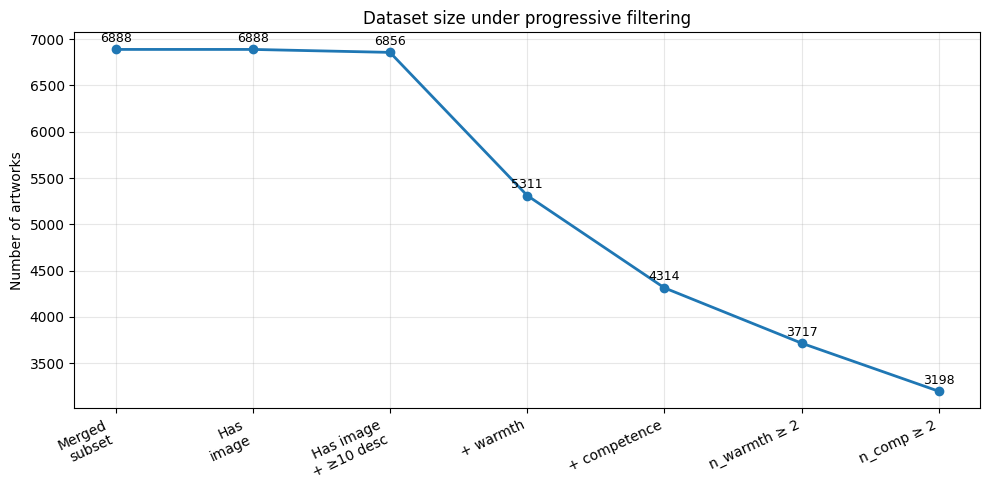

In [50]:
import matplotlib.pyplot as plt

plot_df = audit_summary.copy()

# Updated labels matching the NEW filtering steps
plot_df["step_clean"] = [
    "Merged\nsubset",
    "Has\nimage",
    "Has image\n+ ≥10 desc",
    "+ warmth",
    "+ competence",
    "n_warmth ≥ 2",
    "n_comp ≥ 2"
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["step_clean"],
    plot_df["n"],
    marker="o",
    linewidth=2,
    markersize=6
)

# Add value labels on top of points (clean touch for report)
for x, y in zip(plot_df["step_clean"], plot_df["n"]):
    plt.text(x, y + 80, str(y), ha='center', fontsize=9)

plt.ylabel("Number of artworks")
plt.title("Dataset size under progressive filtering")
plt.xticks(rotation=25, ha="right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The filtering audit illustrates how progressively stricter constraints reduce the dataset size while improving the reliability of the target variables. Starting from 6,888 artworks in the merged subset, requiring a minimum number of extracted descriptors (at least 10) has only a limited impact, reducing the dataset slightly to 6,856 observations.

The most significant reduction occurs when enforcing the availability of both warmth and competence scores, which decreases the dataset to 4,314 artworks. This indicates that a substantial portion of artworks lack sufficient textual signal to support both stereotype dimensions simultaneously.

Further filtering based on descriptor reliability shows a clear trade-off between data quality and sample size. Imposing a minimum of two contributing words for each dimension reduces the dataset to 3,198 artworks. This step ensures that the warmth and competence scores are supported by sufficient textual evidence, improving their interpretability and robustness.

Overall, the audit demonstrates that while stricter filtering reduces the dataset size, it substantially improves the quality of the target variables. This justifies the use of a strict dataset for the main analysis, while alternative versions with relaxed constraints can be used to assess robustness.

## 6. Descriptor coverage and textual signal strength

Before analyzing warmth and competence directly, it is useful to examine the amount of textual evidence available for each artwork. Since the SADCAT scores depend on matched dictionary descriptors, the number of descriptors per artwork affects how reliable the benchmark targets are likely to be.

This section summarizes descriptor coverage and shows how many artworks remain under different minimum thresholds of matched dictionary words.

In [51]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect(db_path)

descriptor_df = pd.read_sql_query(
    """
    SELECT
        n_descriptores_fila,
        n_en_diccionario_fila,
        cov_pct_global
    FROM artwork_sadcat
    """,
    conn
)

conn.close()

print("Basic statistics:")
display(descriptor_df.describe().round(2))

print("Percentiles:")
display(descriptor_df.quantile([0.10, 0.25, 0.50, 0.75, 0.90]).round(2))

Basic statistics:


,n_descriptores_fila,n_en_diccionario_fila,cov_pct_global
count,6888.00,6888.00,6888.00
mean,402.44,28.14,7.31
std,490.47,32.47,3.15
min,1.00,0.00,0.00
25%,74.00,5.00,5.81
50%,206.50,15.00,7.06
75%,562.25,40.00,8.46
max,9121.00,420.00,100.00


Percentiles:


,n_descriptores_fila,n_en_diccionario_fila,cov_pct_global
0.10,30.00,2.0,4.46
0.25,74.00,5.0,5.81
0.50,206.50,15.0,7.06
0.75,562.25,40.0,8.46
0.90,1092.60,75.0,10.42


In [53]:
threshold_rows = []
for k in [1, 2, 3, 5, 10, 20]:
    count = (descriptor_df["n_en_diccionario_fila"] >= k).sum()
    pct = round(count / len(descriptor_df) * 100, 2)
    threshold_rows.append({
        "min_dictionary_words": k,
        "n_artworks": count,
        "pct_of_sadcat_table": pct
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,min_dictionary_words,n_artworks,pct_of_sadcat_table
0,1,6719,97.55
1,2,6399,92.90
2,3,5979,86.80
3,5,5303,76.99
4,10,4291,62.30
5,20,2979,43.25


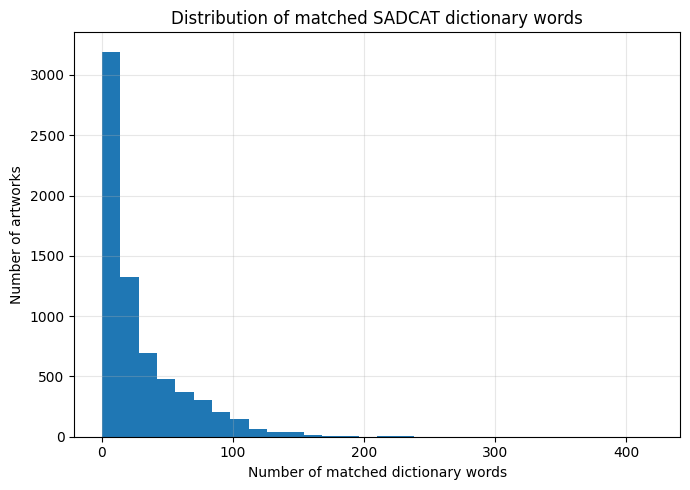

In [54]:
plt.figure(figsize=(7, 5))
plt.hist(descriptor_df["n_en_diccionario_fila"].dropna(), bins=30)
plt.title("Distribution of matched SADCAT dictionary words")
plt.xlabel("Number of matched dictionary words")
plt.ylabel("Number of artworks")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

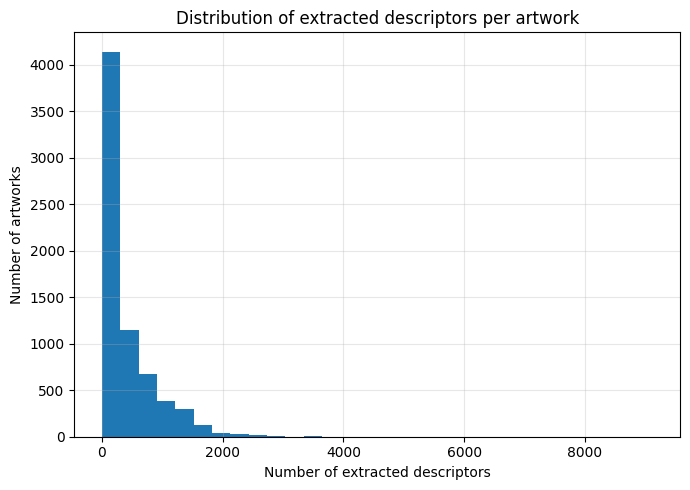

In [55]:
plt.figure(figsize=(7, 5))
plt.hist(descriptor_df["n_descriptores_fila"].dropna(), bins=30)
plt.title("Distribution of extracted descriptors per artwork")
plt.xlabel("Number of extracted descriptors")
plt.ylabel("Number of artworks")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The analysis of descriptor coverage reveals that, although a large number of textual descriptors are extracted per artwork, only a relatively small proportion of them match the SADCAT dictionary. On average, artworks contain around 402 extracted descriptors, but only about 28 correspond to dictionary terms associated with stereotype dimensions, resulting in a low average coverage of approximately 7%. This indicates that most extracted text does not directly contribute to the construction of warmth and competence scores.

The distribution of matched dictionary words is highly skewed, with many artworks containing only a small number of relevant descriptors and a long tail of observations with higher coverage. This suggests that the strength of the textual signal varies substantially across artworks, leading to differences in the reliability of the derived stereotype scores.

The threshold analysis further highlights this variability. While over 97% of artworks contain at least one matched descriptor, this proportion decreases steadily as stricter thresholds are applied. For instance, requiring at least 10 matched words reduces the dataset to approximately 62% of artworks, and requiring 20 words reduces it further to around 43%.

Overall, these results confirm that the availability of stereotype-related textual information is uneven across the dataset. This justifies the application of filtering criteria based on descriptor availability and minimum contribution thresholds, ensuring that the final dataset used for modeling is supported by sufficiently strong textual evidence.

## 7. Distribution of warmth and competence scores

After examining descriptor coverage, the next step is to analyze the distribution of the target variables derived from the SADCAT framework. Understanding how warmth and competence scores are distributed is essential, as it directly affects the ability of models to learn meaningful patterns.

In particular, we examine the presence of skewness, imbalance, and potential ceiling effects in both dimensions.

In [56]:
# Extract warmth and competence from the base dataset

targets_df = master_df[[
    "dirmean_Warmth",
    "dirmean_Competence"
]].dropna()

targets_df.describe().round(3)

,dirmean_Warmth,dirmean_Competence
count,4314.000,4314.000
mean,0.287,0.759
std,0.553,0.348
min,-1.000,-1.000
25%,0.000,0.625
50%,0.333,0.876
75%,0.667,1.000
max,1.000,1.000


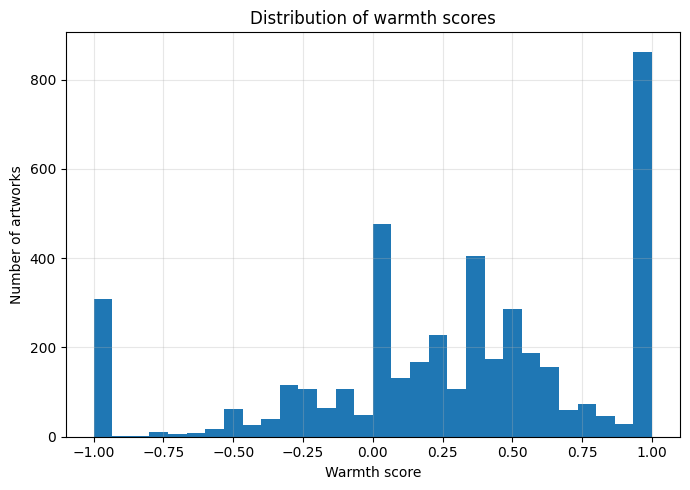

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.hist(targets_df["dirmean_Warmth"], bins=30)
plt.title("Distribution of warmth scores")
plt.xlabel("Warmth score")
plt.ylabel("Number of artworks")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

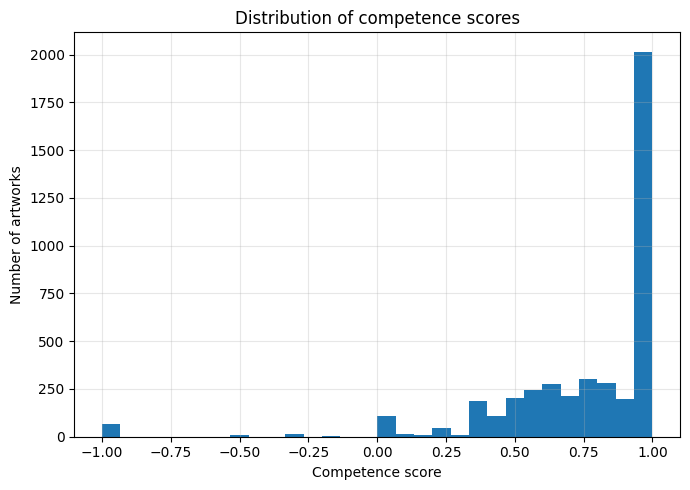

In [58]:
plt.figure(figsize=(7, 5))
plt.hist(targets_df["dirmean_Competence"], bins=30)
plt.title("Distribution of competence scores")
plt.xlabel("Competence score")
plt.ylabel("Number of artworks")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

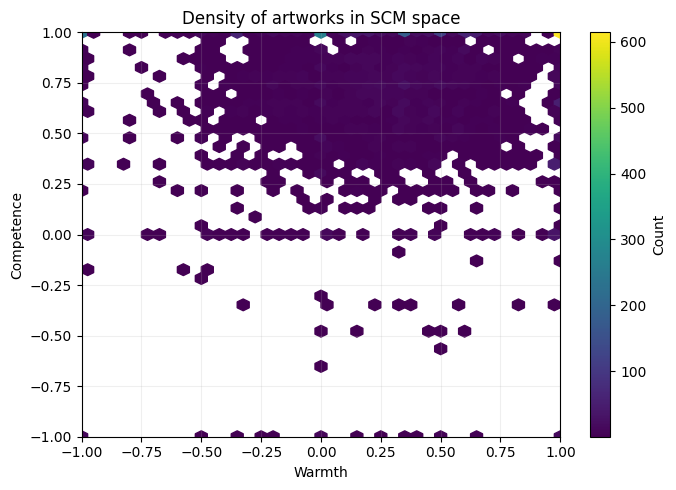

In [59]:
plt.figure(figsize=(7, 5))

hb = plt.hexbin(
    targets_df["dirmean_Warmth"],
    targets_df["dirmean_Competence"],
    gridsize=40,
    mincnt=1
)

plt.colorbar(hb, label="Count")

plt.title("Density of artworks in SCM space")
plt.xlabel("Warmth")
plt.ylabel("Competence")

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation of Warmth and Competence Distributions

The distributions of warmth and competence reveal important structural properties of the final dataset that directly impact the modeling stage.

The warmth dimension exhibits a relatively wide spread across the full range from −1 to 1, although values are more concentrated on the positive side. This indicates that, while artworks tend to be described using somewhat favorable traits, there is still meaningful variability in warmth scores that can potentially be captured by predictive models.

In contrast, competence displays a strong skew toward high values, with a clear concentration of observations near the upper bound. This produces a pronounced ceiling effect, where a large proportion of artworks receive very high competence scores. This pattern is likely driven by the nature of museum descriptions, which tend to emphasize artistic skill, mastery, and status.

The joint distribution further reinforces this imbalance. Most artworks are concentrated in the upper region of the SCM space, particularly in areas characterized by high competence and moderately to highly positive warmth. Lower-competence regions are sparsely populated, and very few observations fall into the lower-left quadrant of the space.

Overall, these findings indicate that the SCM space is unevenly represented in the dataset, with a strong bias toward high-competence portrayals. This has direct implications for the learning task: models are trained on targets with limited variability—especially along the competence dimension—which may constrain their ability to capture nuanced relationships from visual embeddings.

In particular:
- Warmth provides a more informative signal due to its broader distribution  
- Competence is affected by a strong ceiling effect, reducing its effective variability  
- The imbalance in the SCM space may limit the ability of regression models to learn robust patterns  

### 8. Exporting the final strict dataset

After inspecting descriptor coverage and target distributions, the strict dataset is selected as the main dataset for modeling. This version prioritizes stronger textual evidence by requiring at least 10 extracted descriptors per artwork, non-missing warmth and competence scores, and a minimum of two matched dictionary terms contributing to each dimension.

Saving this dataset at this stage ensures that all subsequent embedding and modeling steps use a fixed and reproducible input, maintaining consistency across experiments.

In [60]:
# Save final strict dataset (main dataset for modeling)

strict_df.to_csv("final_dataset_strict.csv", index=False)

print("Saved final_dataset_strict.csv")
print("Shape:", strict_df.shape)

Saved final_dataset_strict.csv
Shape: (3198, 19)


In [61]:
# Save neutral dataset (for robustness experiments later)

neutral_df.to_csv("final_dataset_neutral.csv", index=False)

print("Saved final_dataset_neutral.csv")
print("Shape:", neutral_df.shape)

Saved final_dataset_neutral.csv
Shape: (6856, 21)
